**Setting up the Environment**

In [1]:
# Install required libraries
!pip install pandas numpy xgboost matplotlib seaborn


**Loading and Inspecting Dataset**

In [2]:
import pandas as pd
import numpy as np

# Load dataset from URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)

# Quick inspection
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Data Cleaning**

In [3]:
# Remove canceled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove negative or zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check cleaned data
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.0+ MB


**Aggregate Weekly Sales**

In [4]:
# Aggregate weekly sales per product
sales = df.groupby(['StockCode', pd.Grouper(key='InvoiceDate', freq='W')]).agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean'
}).reset_index()

sales.head()


,StockCode,InvoiceDate,Quantity,UnitPrice
0,10002,2010-12-05,70,1.081429
1,10002,2010-12-12,138,1.197143
2,10002,2010-12-19,41,1.255000
3,10002,2010-12-26,2,1.660000
4,10002,2011-01-09,73,1.120000


**Feature Engineering**

In [5]:
# Create time features
sales['Week'] = sales['InvoiceDate'].dt.isocalendar().week
sales['Month'] = sales['InvoiceDate'].dt.month
sales['Year'] = sales['InvoiceDate'].dt.year

# Lagged sales features
sales['Lag1_Week'] = sales.groupby('StockCode')['Quantity'].shift(1)
sales['Lag2_Week'] = sales.groupby('StockCode')['Quantity'].shift(2)
sales['Rolling_Mean_4weeks'] = sales.groupby('StockCode')['Quantity'].shift(1).rolling(window=4).mean()

# Price change feature
sales['Price_Change'] = sales.groupby('StockCode')['UnitPrice'].pct_change()

# Drop NaN values after creating features
sales.dropna(inplace=True)

sales.head()


,StockCode,InvoiceDate,Quantity,UnitPrice,Week,Month,Year,Lag1_Week,Lag2_Week,Rolling_Mean_4weeks,Price_Change
4,10002,2011-01-09,73,1.1200,1,1,2011,2.0,41.0,62.75,-0.325301
5,10002,2011-01-16,42,0.8500,2,1,2011,73.0,2.0,63.50,-0.241071
6,10002,2011-01-23,76,0.9475,3,1,2011,42.0,73.0,39.50,0.114706
7,10002,2011-01-30,17,1.1100,4,1,2011,76.0,42.0,48.25,0.171504
8,10002,2011-02-06,133,0.8500,5,2,2011,17.0,76.0,52.00,-0.234234


**Train-Test Split**

In [6]:
# Split by date (temporal split)
train = sales[sales['InvoiceDate'] < '2011-10-01']
test = sales[sales['InvoiceDate'] >= '2011-10-01']

features = ['Lag1_Week', 'Lag2_Week', 'Rolling_Mean_4weeks', 'Price_Change', 'Week', 'Month', 'Year']

X_train = train[features]
y_train = train['Quantity']

X_test = test[features]
y_test = test['Quantity']


**BASELINE MODEL (Linear Regression)**

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print("Baseline (Linear Regression) Performance:")
print(f"MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}")


Baseline (Linear Regression) Performance:
MAE: 47.68, RMSE: 120.11


**Demand Forecasting with XGBoost**

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model training
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
preds = model.predict(X_test)

# Evaluation
proposed_mae = mean_absolute_error(y_test, preds)
proposed_rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"MAE: {proposed_mae:.2f}, RMSE: {proposed_rmse:.2f}")



MAE: 65.14, RMSE: 146.53


**Inventory Optimization Simulation (EOQ & Safety Stock)**

In [9]:
# Inventory calculations for an example product
example_product = test.iloc[0]['StockCode']

product_sales = test[test['StockCode'] == example_product]
forecasted_weekly_demand = product_sales['Quantity'].mean()
annual_demand = forecasted_weekly_demand * 52

ordering_cost = 50  # Assume $50 ordering cost
holding_cost = 5    # Assume $5 per unit annual holding cost

# Economic Order Quantity (EOQ)
EOQ = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

# Safety stock calculation (95% service level, Z-score=1.65, 2 weeks lead time)
std_demand = product_sales['Quantity'].std()
lead_time = 2  # weeks
Z = 1.65  # 95% service level
safety_stock = Z * std_demand * np.sqrt(lead_time)

print(f"EOQ: {EOQ:.2f} units")
print(f"Safety Stock: {safety_stock:.2f} units")


EOQ: 127.26 units
Safety Stock: 23.41 units


**Visualization of Results**

**Project Results & Summary**

**MODEL COMPARISON **

In [11]:
print(f"""
--- Demand Forecasting Performance ---
Baseline (Linear Regression): MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}
Proposed (XGBoost): MAE: {proposed_mae:.2f}, RMSE: {proposed_rmse:.2f}

--- Recommended Inventory Levels ---
Economic Order Quantity (EOQ): {EOQ:.2f} units
Safety Stock: {safety_stock:.2f} units
""")



--- Demand Forecasting Performance ---
Baseline (Linear Regression): MAE: 47.68, RMSE: 120.11
Proposed (XGBoost): MAE: 65.14, RMSE: 146.53

--- Recommended Inventory Levels ---
Economic Order Quantity (EOQ): 127.26 units
Safety Stock: 23.41 units



                          Model        MAE        RMSE
0  Linear Regression (Baseline)  47.681931  120.108620
1            XGBoost (Proposed)  65.137489  146.534925


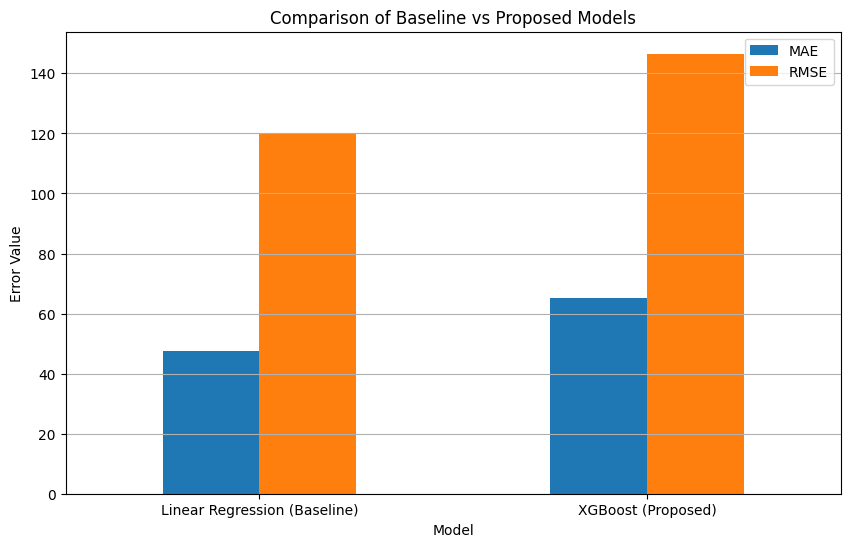

In [10]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'XGBoost (Proposed)'],
    'MAE': [baseline_mae, proposed_mae],
    'RMSE': [baseline_rmse, proposed_rmse]
})

print(comparison_df)

import matplotlib.pyplot as plt

comparison_df.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10,6))
plt.title('Comparison of Baseline vs Proposed Models')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


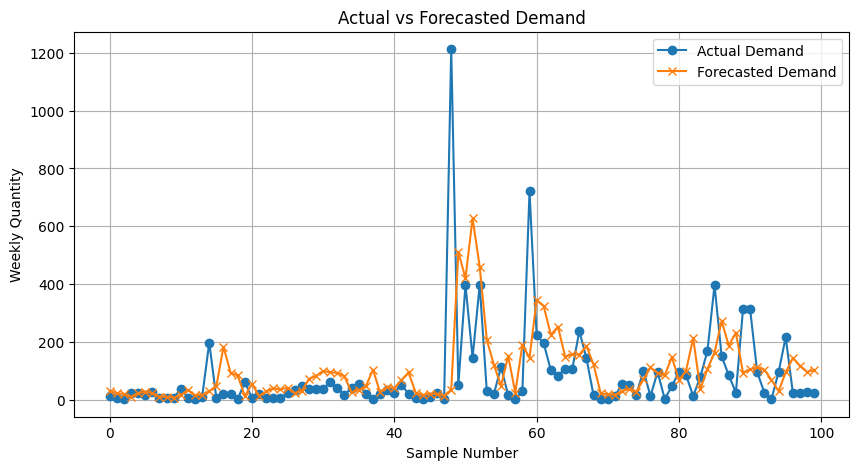

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted visualization
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual Demand', marker='o')
plt.plot(preds[:100], label='Forecasted Demand', marker='x')
plt.xlabel('Sample Number')
plt.ylabel('Weekly Quantity')
plt.title('Actual vs Forecasted Demand')
plt.legend()
plt.grid(True)
plt.show()
